In [12]:
!python -m pip install pandas
!python -m pip install matplotlib


Total number of occurrences: 34

Number of occurrences per category:
category_column
Electronics      9
Clothing         9
Books            8
Home & Garden    4
Toys             4
Name: count, dtype: int64

Most frequent category: Electronics (Count: 9)

Time with least occurrences: 2024-01-02 (Count: 8)
Time with most occurrences: 2024-01-01 (Count: 10)


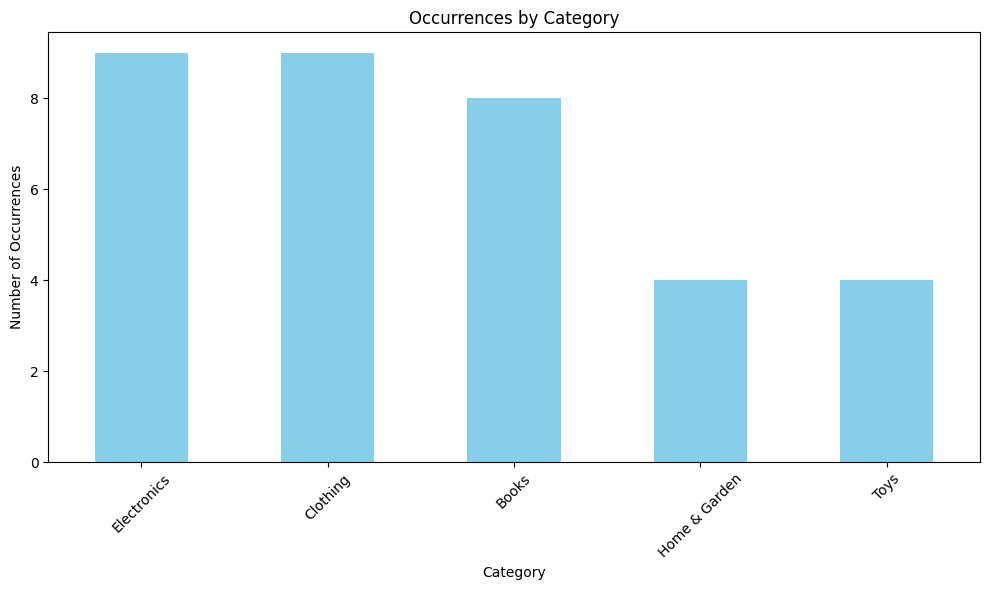

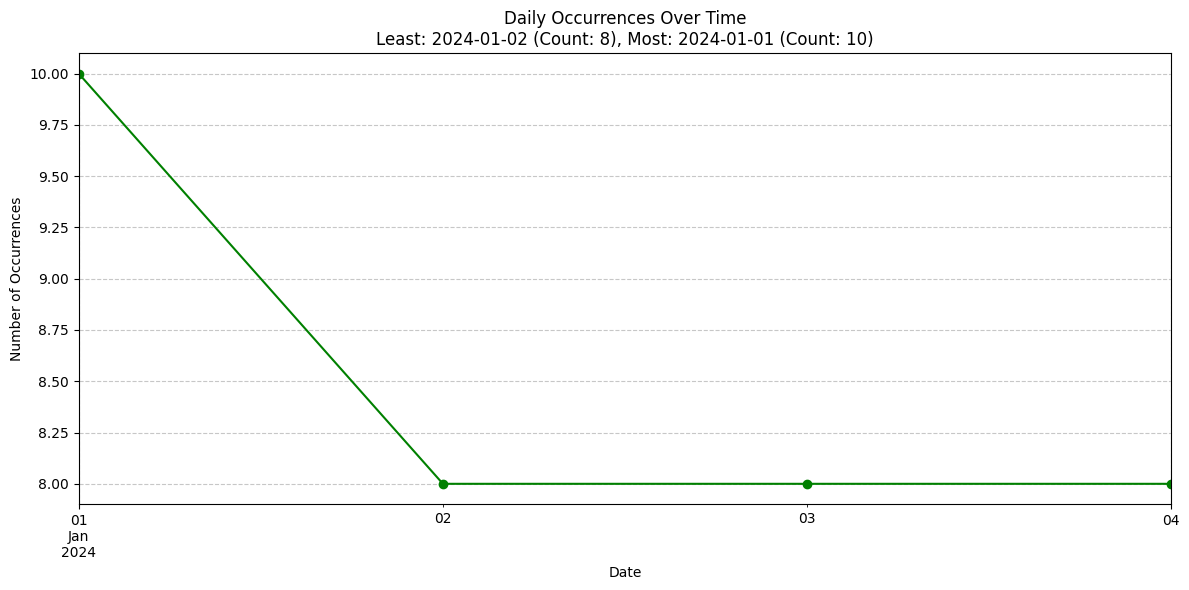

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('pandas_store.csv')

# 2. Basic statistics
total_occurrences = len(df)
print(f"Total number of occurrences: {total_occurrences}")

category_counts = df['category_column'].value_counts()
print("\nNumber of occurrences per category:")
print(category_counts)

most_frequent_category = category_counts.idxmax()
most_frequent_count = category_counts.max()
print(f"\nMost frequent category: {most_frequent_category} (Count: {most_frequent_count})")

# 3. Time analysis
df['timestamp_column'] = pd.to_datetime(df['timestamp_column'])
time_counts = df.set_index('timestamp_column').resample('D').size()

least_time = time_counts.idxmin()
least_count = time_counts.min()
most_time = time_counts.idxmax()
most_count = time_counts.max()

print(f"\nTime with least occurrences: {least_time.strftime('%Y-%m-%d')} (Count: {least_count})")
print(f"Time with most occurrences: {most_time.strftime('%Y-%m-%d')} (Count: {most_count})")

# 4. Plot 1: Occurrences by Category (Bar Plot)
plt.figure(figsize=(10, 6))
category_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Category')
plt.ylabel('Number of Occurrences')
plt.title('Occurrences by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Plot 2: Occurrences by Date (Line Plot)
plt.figure(figsize=(12, 6))
time_counts.plot(kind='line', marker='o', color='green', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Number of Occurrences')
plt.title(
    'Daily Occurrences Over Time\n' +
    f'Least: {least_time.strftime("%Y-%m-%d")} (Count: {least_count}), ' +
    f'Most: {most_time.strftime("%Y-%m-%d")} (Count: {most_count})'
)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()